# 🔍 Anomaly Detection for Best-Effort Traffic

**Business objective:** Identify traffic flows where premium (GBR) or guaranteed traffic is  
misclassified or routed into best-effort, non-guaranteed slices — threatening SLA compliance  
and customer trust.

## Pipeline architecture

```
Raw data → Feature Engineering
                ├─ Isolation Forest   (unsupervised, no labels needed)
                ├─ One-Class SVM      (semi-supervised, fit on normals only)
                ├─ Reconstruction AE  (semi-supervised, fit on normals only)
                        └──────────────────────────────► Weighted Ensemble Score
                                                                 ↓
                                              Risk tier (Low / Medium / High)
```

## Why semi-supervised?
No pre-labeled anomalies exist. We derive **weak supervision labels** from 5G domain rules,  
then inject **15 % label noise** to simulate real-world labeling uncertainty and prevent  
the model from trivially memorising the rules.

---
## Table of Contents
1. [Setup & Data Loading](#1)
2. [Preprocessing & Feature Engineering](#2)
3. [Anomaly Label Construction](#3)
4. [Exploratory Anomaly Analysis](#4)
5. [Model 1 — Isolation Forest](#5)
6. [Model 2 — One-Class SVM](#6)
7. [Model 3 — Reconstruction Autoencoder](#7)
9. [Ensemble Fusion & Model Comparison](#9)
10. [Evaluation & Calibration](#10)
12. [Risk Tiers & Final Output](#12)
13. [Summary](#13)

<a id='1'></a>
---
## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, precision_recall_curve, roc_curve,
    f1_score, brier_score_loss
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import xgboost as xgb
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

SLICE_COLORS  = {1: '#2ecc71', 2: '#3498db', 3: '#e74c3c'}
SLICE_LABELS  = {1: 'Type 1 (eMBB)', 2: 'Type 2 (URLLC)', 3: 'Type 3 (mIoT)'}
TIER_PAL      = {'Low': '#27ae60', 'Medium': '#f39c12', 'High': '#e74c3c'}

print('Libraries loaded ✔')

Libraries loaded ✔


In [2]:
train_raw = pd.read_csv('train_prepared_5g.csv').drop_duplicates().reset_index(drop=True)
test_raw  = pd.read_csv('test_prepared_5g.csv').drop_duplicates().reset_index(drop=True)

print(f'Train : {train_raw.shape[0]:,} rows × {train_raw.shape[1]} columns')
print(f'Test  : {test_raw.shape[0]:,} rows × {test_raw.shape[1]} columns')
print()
print('Slice distribution (train):')
for k, v in train_raw['slice Type'].value_counts().sort_index().items():
    print(f'  {SLICE_LABELS[k]}: {v:,} ({v/len(train_raw)*100:.1f}%)')
print()
print('GBR distribution (train):')
gbr = train_raw['GBR'].value_counts()
print(f'  GBR = 1 (premium/guaranteed) : {gbr[1]:,} ({gbr[1]/len(train_raw)*100:.1f}%)')
print(f'  GBR = 0 (best-effort)         : {gbr[0]:,} ({gbr[0]/len(train_raw)*100:.1f}%)')

Train : 8,958 rows × 30 columns
Test  : 8,960 rows × 29 columns

Slice distribution (train):
  Type 1 (eMBB): 4,772 (53.3%)
  Type 2 (URLLC): 2,088 (23.3%)
  Type 3 (mIoT): 2,098 (23.4%)

GBR distribution (train):
  GBR = 1 (premium/guaranteed) : 3,953 (44.1%)
  GBR = 0 (best-effort)         : 5,005 (55.9%)


<a id='2'></a>
---
## 2. Preprocessing & Feature Engineering

| Step | What | Why |
|---|---|---|
| Drop `LTE/5G`, `Non-GBR` | Perfect redundancy (`LTE/5G = 1−IoT`, `Non-GBR = 1−GBR`) | Eliminate multicollinearity |
| Cyclic time | `sin` + `cos` of hour | Hour 23 ↔ hour 0 are neighbors; raw int distorts this |
| `log_plr`, `log_delay` | Log-scale QoS features | Loss rates span 4 orders of magnitude |
| `qos_strictness` | Weighted PLR + delay risk | Composite SLA sensitivity — key anomaly signal |
| `gbr_x_strictness` | GBR × QoS strictness | Premium traffic under strict QoS = highest violation risk |
| Use-case groups | 3 aggregated flags | Reduces sparsity, preserves domain meaning |

In [3]:
USE_CASE_COLS = [
    'AR/VR/Gaming', 'Healthcare', 'Industry 4.0', 'IoT Devices',
    'Public Safety', 'Smart City & Home', 'Smart Transportation', 'Smartphone'
]

# 5G domain: lower loss / lower delay = stricter SLA = higher impact if violated
PLR_RISK_MAP   = {1e-6: 1.0, 1e-3: 0.5, 1e-2: 0.0}
DELAY_RISK_MAP = {10: 1.0, 50: 0.8, 60: 0.7, 75: 0.6, 100: 0.4, 150: 0.2, 300: 0.0}


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Drop perfectly redundant columns
    df.drop(columns=[c for c in ['LTE/5G', 'Non-GBR'] if c in df.columns], inplace=True)

    # Cyclic time
    df['time_sin'] = np.sin(2 * np.pi * df['Time'] / 24)
    df['time_cos'] = np.cos(2 * np.pi * df['Time'] / 24)
    df['is_peak']  = (((df['Time'] >= 8)  & (df['Time'] <= 10)) |
                      ((df['Time'] >= 18) & (df['Time'] <= 21))).astype(int)

    # Log-scale QoS
    df['log_plr']   = np.log10(df['Packet Loss Rate'].clip(1e-9))
    df['log_delay'] = np.log10(df['Packet delay'])

    # QoS strictness score (60 % loss risk + 40 % delay risk)
    plr_r  = df['Packet Loss Rate'].map(PLR_RISK_MAP).fillna(0.5)
    dly_r  = df['Packet delay'].map(DELAY_RISK_MAP).fillna(0.5)
    df['qos_strictness']   = 0.6 * plr_r + 0.4 * dly_r

    # Interaction features
    df['gbr_x_strict']  = df['GBR']      * df['qos_strictness']
    df['peak_x_strict'] = df['is_peak']  * df['qos_strictness']

    # Use-case aggregation
    df['n_use_cases']    = df[USE_CASE_COLS].sum(axis=1)
    df['is_mc']          = df[['Healthcare', 'Public Safety', 'Smart Transportation']].max(axis=1).astype(int)
    df['is_consumer']    = df[['Smartphone', 'AR/VR/Gaming']].max(axis=1).astype(int)
    df['is_industrial']  = df[['Industry 4.0', 'IoT Devices', 'Smart City & Home']].max(axis=1).astype(int)

    return df


train = engineer_features(train_raw)
test  = engineer_features(test_raw)

FEATURE_COLS = [
    'LTE/5g Category', 'time_sin', 'time_cos', 'is_peak',
    'log_plr', 'log_delay', 'qos_strictness',
    'IoT', 'GBR', 'gbr_x_strict', 'peak_x_strict',
    'n_use_cases', 'is_mc', 'is_consumer', 'is_industrial'
] + USE_CASE_COLS

print(f'Feature engineering complete ✔  →  {len(FEATURE_COLS)} features')
print(f'Train: {train.shape}  |  Test: {test.shape}')

Feature engineering complete ✔  →  23 features
Train: (8958, 40)  |  Test: (8960, 39)


<a id='3'></a>
---
## 3. Anomaly Label Construction

No pre-labeled anomalies exist — we derive them from 5G domain rules:

| Rule | Condition | Meaning |
|---|---|---|
| **R1** | GBR=1 AND PLR ≥ 1e-2 | Premium traffic in lossy best-effort conditions |
| **R2** | GBR=1 AND delay ≥ 150 ms AND slice ∈ {1,2} | Premium traffic with unacceptable latency |
| **R3** | Slice 2 (URLLC IoT) AND GBR=0 | IoT URLLC traffic without the GBR guarantee it requires |

These rules produce **clean, deterministic ground-truth labels** used for training all models and all evaluation metrics.

In [4]:

def build_labels(df: pd.DataFrame) -> pd.Series:
    """
    Derive binary anomaly ground-truth labels from 5G domain rules.
    Returns a clean integer Series — no label noise needed without XGBoost.
    """
    y = pd.Series(0, index=df.index, dtype=int)

    # R1: GBR premium traffic with unacceptably high packet loss
    y[(df['GBR'] == 1) & (df['Packet Loss Rate'] >= 1e-2)] = 1
    # R2: GBR premium traffic with unacceptably high latency in eMBB/URLLC slices
    y[(df['GBR'] == 1) & (df['Packet delay'] >= 150)
      & (df['slice Type'].isin([1, 2]))] = 1
    # R3: Slice 2 IoT URLLC traffic without the GBR guarantee it requires
    y[(df['slice Type'] == 2) & (df['GBR'] == 0)] = 1

    return y


y_clean = build_labels(train)
train['is_anomaly'] = y_clean

n_anom = y_clean.sum()
print(f'Anomaly labels constructed ✔')
print(f'  Anomalies : {n_anom:,} / {len(y_clean):,} rows  ({n_anom/len(y_clean)*100:.1f}%)')
print(f'  Normal    : {(len(y_clean)-n_anom):,} / {len(y_clean):,} rows  ({(1-y_clean.mean())*100:.1f}%)')
print()
r1 = int(((train['GBR']==1) & (train['Packet Loss Rate']>=1e-2)).sum())
r2 = int(((train['GBR']==1) & (train['Packet delay']>=150) & train['slice Type'].isin([1,2])).sum())
r3 = int(((train['slice Type']==2) & (train['GBR']==0)).sum())
print(f'  R1 (GBR + high PLR)    : {r1:,}')
print(f'  R2 (GBR + high delay)  : {r2:,}')
print(f'  R3 (Slice 2 + Non-GBR) : {r3:,}')
print(f'  Union (with overlaps)  : {n_anom:,}')
print()
print('Anomaly rate by slice type:')
for st in [1, 2, 3]:
    sub = train[train['slice Type'] == st]
    rate = sub['is_anomaly'].mean() * 100
    print(f'  {SLICE_LABELS[st]}: {rate:.1f}%  ({sub["is_anomaly"].sum()} rows)')


Anomaly labels constructed ✔
  Anomalies : 2,041 / 8,958 rows  (22.8%)
  Normal    : 6,917 / 8,958 rows  (77.2%)

  R1 (GBR + high PLR)    : 1,042
  R2 (GBR + high delay)  : 1,519
  R3 (Slice 2 + Non-GBR) : 522
  Union (with overlaps)  : 2,041

Anomaly rate by slice type:
  Type 1 (eMBB): 10.0%  (477 rows)
  Type 2 (URLLC): 74.9%  (1564 rows)
  Type 3 (mIoT): 0.0%  (0 rows)


<a id='4'></a>
---
## 4. Exploratory Anomaly Analysis

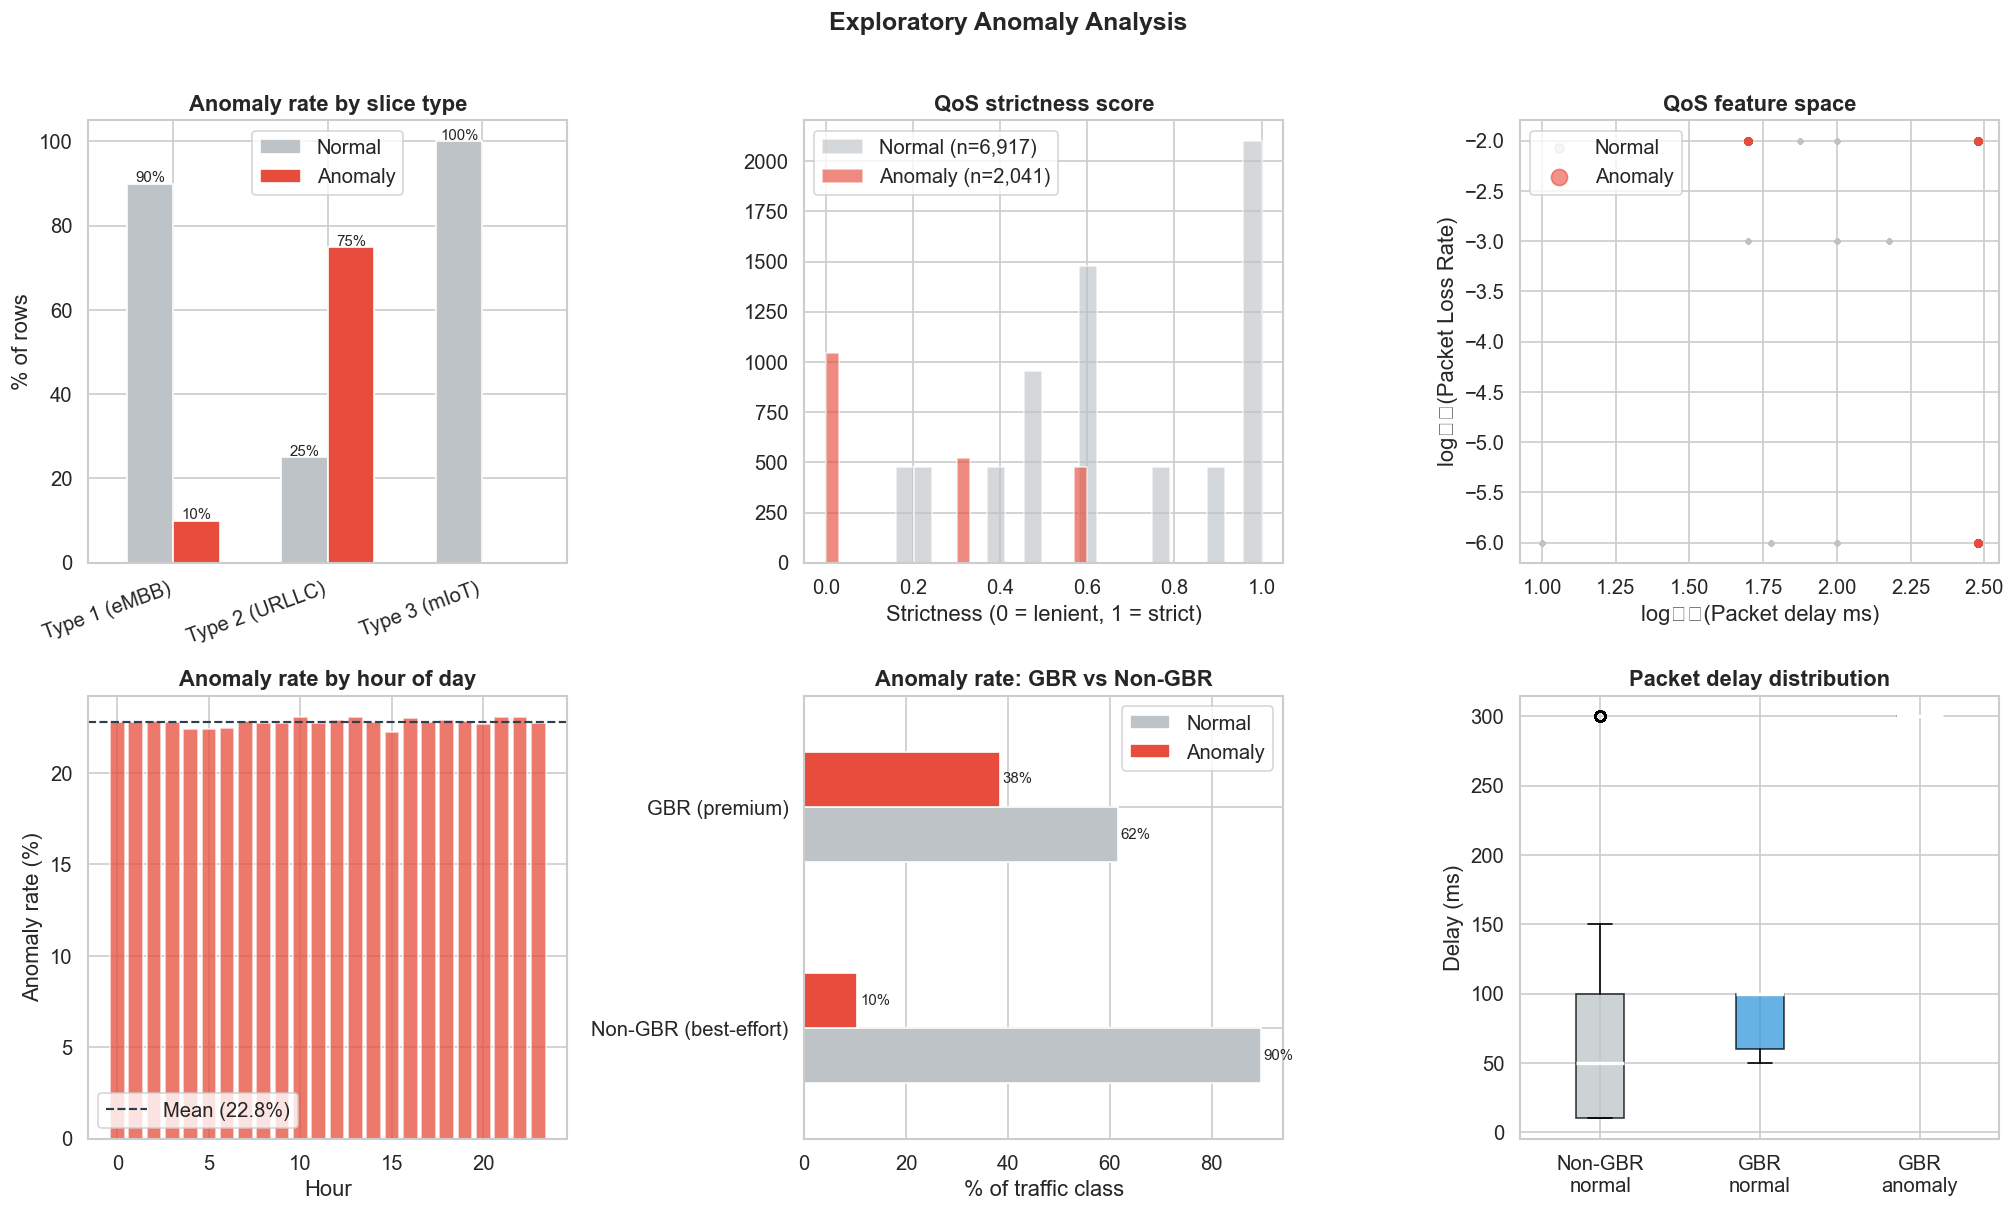

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# ── 4.1 Anomaly rate by slice type ───────────────────────────────────────────
ax = axes[0, 0]
ct = pd.crosstab(train['slice Type'], train['is_anomaly'], normalize='index') * 100
ct.plot(kind='bar', ax=ax, color=['#bdc3c7', '#e74c3c'], edgecolor='white', width=0.6)
ax.set_title('Anomaly rate by slice type', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('% of rows')
ax.set_xticklabels([SLICE_LABELS[i] for i in ct.index], rotation=20, ha='right')
ax.legend(['Normal', 'Anomaly'])
for p in ax.patches:
    if p.get_height() > 3:
        ax.text(p.get_x() + p.get_width()/2, p.get_height() + 0.4,
                f'{p.get_height():.0f}%', ha='center', fontsize=9)

# ── 4.2 QoS strictness distribution ──────────────────────────────────────────
ax = axes[0, 1]
for lab, col, nm in [(0,'#bdc3c7','Normal'),(1,'#e74c3c','Anomaly')]:
    sub = train[train['is_anomaly']==lab]['qos_strictness']
    ax.hist(sub, bins=20, alpha=0.65, color=col,
            label=f'{nm} (n={len(sub):,})', edgecolor='white')
ax.set_title('QoS strictness score', fontweight='bold')
ax.set_xlabel('Strictness (0 = lenient, 1 = strict)')
ax.legend()

# ── 4.3 QoS space scatter ────────────────────────────────────────────────────
ax = axes[0, 2]
for lab, col, nm, zo, s in [(0,'#bdc3c7','Normal',1,5),(1,'#e74c3c','Anomaly',2,15)]:
    sub = train[train['is_anomaly']==lab]
    ax.scatter(sub['log_delay'], sub['log_plr'],
               alpha=0.15 if lab==0 else 0.6, s=s, color=col, label=nm, zorder=zo)
ax.set_title('QoS feature space', fontweight='bold')
ax.set_xlabel('log₁₀(Packet delay ms)')
ax.set_ylabel('log₁₀(Packet Loss Rate)')
ax.legend(markerscale=2.5)

# ── 4.4 Anomaly rate by hour ─────────────────────────────────────────────────
ax = axes[1, 0]
hourly = train.groupby('Time')['is_anomaly'].agg(['sum','count'])
hourly['rate'] = hourly['sum'] / hourly['count'] * 100
ax.bar(hourly.index, hourly['rate'], color='#e74c3c', alpha=0.75, edgecolor='white')
ax.axhline(y_clean.mean()*100, color='#2c3e50', ls='--', lw=1.3,
           label=f'Mean ({y_clean.mean()*100:.1f}%)')
ax.set_title('Anomaly rate by hour of day', fontweight='bold')
ax.set_xlabel('Hour')
ax.set_ylabel('Anomaly rate (%)')
ax.legend()

# ── 4.5 GBR × anomaly rate ───────────────────────────────────────────────────
ax = axes[1, 1]
ct2 = pd.crosstab(train['GBR'], train['is_anomaly'], normalize='index') * 100
ct2.index = ['Non-GBR (best-effort)', 'GBR (premium)']
ct2.plot(kind='barh', ax=ax, color=['#bdc3c7','#e74c3c'], edgecolor='white')
ax.set_title('Anomaly rate: GBR vs Non-GBR', fontweight='bold')
ax.set_xlabel('% of traffic class')
ax.legend(['Normal', 'Anomaly'])
for p in ax.patches:
    if p.get_width() > 1:
        ax.text(p.get_width()+0.5, p.get_y()+p.get_height()/2,
                f'{p.get_width():.0f}%', va='center', fontsize=9)

# ── 4.6 Delay distribution: GBR × anomaly ────────────────────────────────────
ax = axes[1, 2]
groups = [
    train[(train['GBR']==0) & (train['is_anomaly']==0)]['Packet delay'],
    train[(train['GBR']==1) & (train['is_anomaly']==0)]['Packet delay'],
    train[(train['GBR']==1) & (train['is_anomaly']==1)]['Packet delay'],
]
bp = ax.boxplot(groups, labels=['Non-GBR\nnormal','GBR\nnormal','GBR\nanomaly'],
                patch_artist=True, medianprops=dict(color='white', lw=2))
for patch, col in zip(bp['boxes'], ['#bdc3c7','#3498db','#e74c3c']):
    patch.set_facecolor(col); patch.set_alpha(0.75)
ax.set_title('Packet delay distribution', fontweight='bold')
ax.set_ylabel('Delay (ms)')

plt.suptitle('Exploratory Anomaly Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

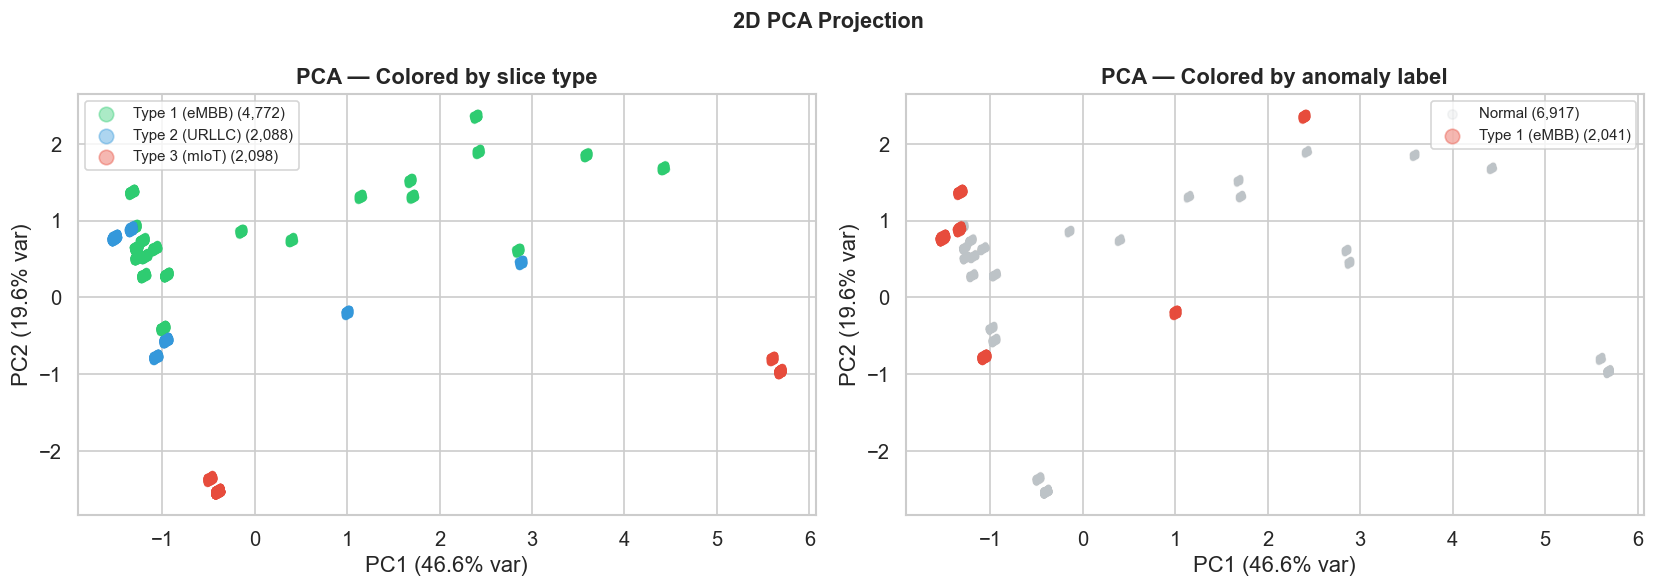

2-component variance explained: 66.2%


In [6]:
# PCA 2-D projection
scaler_viz = RobustScaler()
X_viz = scaler_viz.fit_transform(train[FEATURE_COLS])
pca_viz = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_viz.fit_transform(X_viz)
var = pca_viz.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (c_col, lbl_map), title in zip(
    axes,
    [('slice Type', SLICE_COLORS), ('is_anomaly', {0:'#bdc3c7', 1:'#e74c3c'})],
    ['Colored by slice type', 'Colored by anomaly label']
):
    for val, col in lbl_map.items():
        idx = train[c_col] == val
        name = SLICE_LABELS.get(val, 'Normal' if val==0 else 'Anomaly')
        ax.scatter(X_2d[idx,0], X_2d[idx,1],
                   alpha=0.15 if (c_col=='is_anomaly' and val==0) else 0.4,
                   s=5 if (c_col=='is_anomaly' and val==0) else 12,
                   color=col, label=f'{name} ({idx.sum():,})',
                   zorder=1 if val==0 else 2)
    ax.set_title(f'PCA — {title}', fontweight='bold')
    ax.set_xlabel(f'PC1 ({var[0]:.1f}% var)')
    ax.set_ylabel(f'PC2 ({var[1]:.1f}% var)')
    ax.legend(markerscale=2.5, fontsize=9)

plt.suptitle('2D PCA Projection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'2-component variance explained: {var.sum():.1f}%')

<a id='5'></a>
---
## 5. Model 1 — Isolation Forest

**How it works:** Randomly partitions the feature space. Anomalies require fewer splits  
because they occupy sparse, atypical regions. No labels required.

**Tuning:** Grid-search over `n_estimators` and `max_features`,  
maximising AUC-ROC against clean labels.  
**`contamination`** set to the empirical anomaly rate (domain-rule labels).

In [7]:
X_tr = train[FEATURE_COLS].copy()
X_te = test[FEATURE_COLS].copy()

# RobustScaler: median/IQR normalisation — less distorted by anomalous points
scaler = RobustScaler()
Xtr_s  = scaler.fit_transform(X_tr)
Xte_s  = scaler.transform(X_te)

CONTAMINATION = float(y_clean.mean())
X_normal      = Xtr_s[y_clean == 0]   # normal subset for OC-SVM & AE

print(f'Scaled feature matrix: train {Xtr_s.shape}, test {Xte_s.shape}')
print(f'Contamination         : {CONTAMINATION:.4f}  ({CONTAMINATION*100:.2f}%)')
print(f'Normal samples (OC-SVM/AE fit): {len(X_normal):,}')

Scaled feature matrix: train (8958, 23), test (8960, 23)
Contamination         : 0.2278  (22.78%)
Normal samples (OC-SVM/AE fit): 6,917


In [8]:
print('Tuning Isolation Forest...')
best_if_auc, best_if = 0, None
best_if_params = {}

for n_est in [100, 200, 300]:
    for max_feat in [0.6, 0.8, 1.0]:
        m = IsolationForest(
            n_estimators=n_est, max_features=max_feat,
            contamination=CONTAMINATION, random_state=RANDOM_STATE, n_jobs=-1
        )
        m.fit(Xtr_s)
        sc = -m.score_samples(Xtr_s)
        auc = roc_auc_score(y_clean, sc)
        if auc > best_if_auc:
            best_if_auc = auc
            best_if = m
            best_if_params = {'n_estimators': n_est, 'max_features': max_feat}

sIF_tr = -best_if.score_samples(Xtr_s)
sIF_te = -best_if.score_samples(Xte_s)
# Normalise to [0, 1]
_mn, _mx = sIF_tr.min(), sIF_tr.max()
sIF_tr = (sIF_tr - _mn) / (_mx - _mn)
sIF_te = (sIF_te - _mn) / (_mx - _mn)

if_auc = roc_auc_score(y_clean, sIF_tr)
if_ap  = average_precision_score(y_clean, sIF_tr)
print(f'Best params    : {best_if_params}')
print(f'AUC-ROC        : {if_auc:.4f}')
print(f'Avg Precision  : {if_ap:.4f}')

Tuning Isolation Forest...
Best params    : {'n_estimators': 200, 'max_features': 0.6}
AUC-ROC        : 0.6458
Avg Precision  : 0.2927


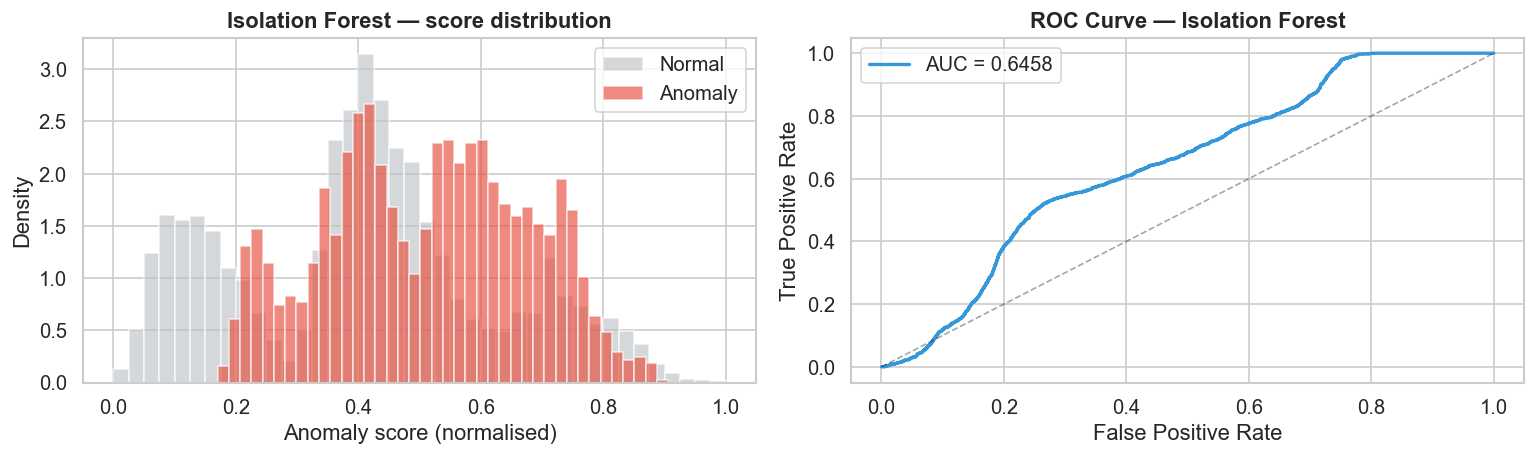

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for lab, col, nm in [(0,'#bdc3c7','Normal'),(1,'#e74c3c','Anomaly')]:
    ax.hist(sIF_tr[y_clean==lab], bins=40, alpha=0.65, color=col,
            label=nm, edgecolor='white', density=True)
ax.set_title('Isolation Forest — score distribution', fontweight='bold')
ax.set_xlabel('Anomaly score (normalised)')
ax.set_ylabel('Density')
ax.legend()

ax = axes[1]
fpr, tpr, _ = roc_curve(y_clean, sIF_tr)
ax.plot(fpr, tpr, color='#3498db', lw=2, label=f'AUC = {if_auc:.4f}')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.35)
ax.set_title('ROC Curve — Isolation Forest', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.tight_layout()
plt.show()

<a id='6'></a>
---
## 6. Model 2 — One-Class SVM

**How it works:** Learns a soft hypersphere around the normal class in RBF kernel space.  
Flows outside the boundary are flagged as anomalous.

**Semi-supervised design:** Fitted **on normal samples only** (using clean labels as a filter).  
This tightens the boundary and improves sensitivity.  
`nu` ≈ upper bound on fraction of outliers — set near the empirical contamination rate.

In [10]:
print(f'Fitting OC-SVM on {len(X_normal):,} normal samples...')
best_oc_auc, best_oc = 0, None
best_oc_params = {}

for gamma in ['scale', 'auto', 0.1]:
    for nu in [CONTAMINATION*0.5, CONTAMINATION, min(CONTAMINATION*1.5, 0.49)]:
        m = OneClassSVM(kernel='rbf', nu=nu, gamma=gamma)
        m.fit(X_normal)
        sc = -m.decision_function(Xtr_s)
        try:
            auc = roc_auc_score(y_clean, sc)
            if auc > best_oc_auc:
                best_oc_auc = auc
                best_oc = m
                best_oc_params = {'gamma': gamma, 'nu': round(float(nu), 4)}
        except Exception:
            pass

sOC_tr = -best_oc.decision_function(Xtr_s)
sOC_te = -best_oc.decision_function(Xte_s)
_mn, _mx = sOC_tr.min(), sOC_tr.max()
sOC_tr = (sOC_tr - _mn) / (_mx - _mn)
sOC_te = (sOC_te - _mn) / (_mx - _mn)

oc_auc = roc_auc_score(y_clean, sOC_tr)
oc_ap  = average_precision_score(y_clean, sOC_tr)
print(f'Best params    : {best_oc_params}')
print(f'AUC-ROC        : {oc_auc:.4f}')
print(f'Avg Precision  : {oc_ap:.4f}')

Fitting OC-SVM on 6,917 normal samples...
Best params    : {'gamma': 0.1, 'nu': 0.1139}
AUC-ROC        : 0.9862
Avg Precision  : 0.9590


<a id='7'></a>
---
## 7. Model 3 — Reconstruction Autoencoder

**How it works:** A PCA-based linear autoencoder trained on normal traffic.  
Anomaly score = per-sample MSE between the input and its reconstruction.  
Anomalous flows reconstruct poorly because they fall outside the learned normal manifold.

**Architecture:** Encoder = PCA projection to `k` components (latent space compression).  
Decoder = PCA inverse transform back to original dimensionality.  
The number of components `k` is tuned by AUC on clean labels.

In [11]:
print('Tuning Reconstruction Autoencoder (number of PCA components)...')
best_ae_auc, best_ae_n, best_ae = 0, 8, None

for n_comp in [4, 6, 8, 10, 12, 15]:
    pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
    pca.fit(X_normal)
    sc = np.mean((Xtr_s - pca.inverse_transform(pca.transform(Xtr_s)))**2, axis=1)
    auc = roc_auc_score(y_clean, sc)
    var_exp = pca.explained_variance_ratio_.sum() * 100
    print(f'  k={n_comp:2d}  AUC={auc:.4f}  var_explained={var_exp:.1f}%')
    if auc > best_ae_auc:
        best_ae_auc = auc
        best_ae_n = n_comp
        best_ae = pca

print(f'\nBest k = {best_ae_n}')

sAE_tr = np.mean((Xtr_s - best_ae.inverse_transform(best_ae.transform(Xtr_s)))**2, axis=1)
sAE_te = np.mean((Xte_s - best_ae.inverse_transform(best_ae.transform(Xte_s)))**2, axis=1)
_mn, _mx = sAE_tr.min(), sAE_tr.max()
sAE_tr = (sAE_tr - _mn) / (_mx - _mn)
sAE_te = (sAE_te - _mn) / (_mx - _mn)

ae_auc = roc_auc_score(y_clean, sAE_tr)
ae_ap  = average_precision_score(y_clean, sAE_tr)
print(f'AUC-ROC       : {ae_auc:.4f}')
print(f'Avg Precision : {ae_ap:.4f}')

Tuning Reconstruction Autoencoder (number of PCA components)...
  k= 4  AUC=0.8716  var_explained=84.2%
  k= 6  AUC=0.8882  var_explained=90.6%
  k= 8  AUC=0.9048  var_explained=95.6%
  k=10  AUC=0.8535  var_explained=97.9%
  k=12  AUC=0.8957  var_explained=99.6%
  k=15  AUC=0.9193  var_explained=100.0%

Best k = 15
AUC-ROC       : 0.9193
Avg Precision : 0.8667


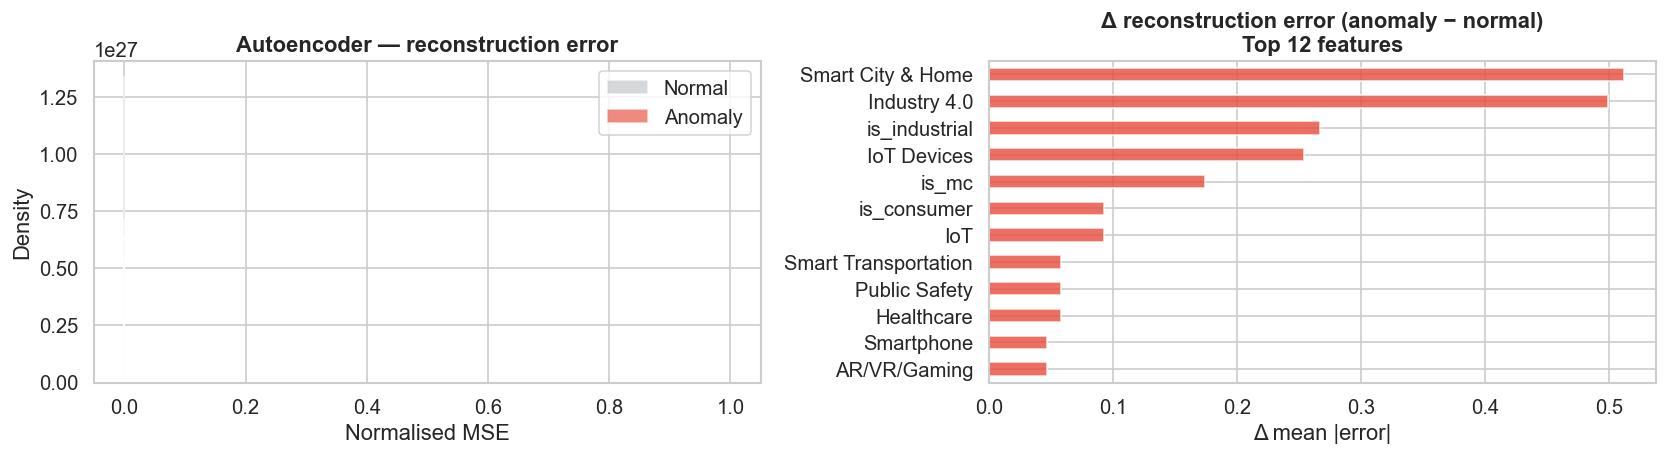

In [12]:
# Per-feature reconstruction error: what does the AE struggle with for anomalies?
X_recon = best_ae.inverse_transform(best_ae.transform(Xtr_s))
err_df  = pd.DataFrame(np.abs(Xtr_s - X_recon), columns=FEATURE_COLS)
err_delta = (err_df[y_clean==1].mean() - err_df[y_clean==0].mean()).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
for lab, col, nm in [(0,'#bdc3c7','Normal'),(1,'#e74c3c','Anomaly')]:
    ax.hist(sAE_tr[y_clean==lab], bins=40, alpha=0.65, color=col,
            label=nm, edgecolor='white', density=True)
ax.set_title('Autoencoder — reconstruction error', fontweight='bold')
ax.set_xlabel('Normalised MSE')
ax.set_ylabel('Density')
ax.legend()

ax = axes[1]
err_delta.head(12).sort_values().plot(kind='barh', ax=ax,
                                      color='#e74c3c', alpha=0.8, edgecolor='white')
ax.set_title('Δ reconstruction error (anomaly − normal)\nTop 12 features', fontweight='bold')
ax.set_xlabel('Δ mean |error|')

plt.tight_layout()
plt.show()

<a id='8'></a>
---
## 8. Ensemble Fusion & Model Comparison

**Weighted average fusion** with AUC²-proportional weights:  
better-performing models contribute more to the final score.  
All four normalised [0, 1] scores are fused into a single `anomaly_score`.

In [13]:
MODEL_NAMES  = ['Isolation Forest', 'One-Class SVM', 'Autoencoder']
SCORES_TR    = [sIF_tr, sOC_tr, sAE_tr]
SCORES_TE    = [sIF_te, sOC_te, sAE_te]
MODEL_COLORS = ['#3498db', '#9b59b6', '#f39c12']

model_aucs = np.array([roc_auc_score(y_clean, s) for s in SCORES_TR])
model_aps  = np.array([average_precision_score(y_clean, s) for s in SCORES_TR])

# AUC²-proportional weights
weights = model_aucs ** 2
weights /= weights.sum()

print(f'{'Model':<22}  {'AUC-ROC':>9}  {'Avg-Prec':>9}  {'Weight':>8}')
print('─' * 57)
for nm, auc, ap, w in zip(MODEL_NAMES, model_aucs, model_aps, weights):
    print(f'{nm:<22}  {auc:>9.4f}  {ap:>9.4f}  {w:>8.4f}')

# Fuse
ens_tr = np.column_stack(SCORES_TR) @ weights
ens_te = np.column_stack(SCORES_TE) @ weights
_mn, _mx = ens_tr.min(), ens_tr.max()
ens_tr = (ens_tr - _mn) / (_mx - _mn)
ens_te = (ens_te - _mn) / (_mx - _mn)

ens_auc = roc_auc_score(y_clean, ens_tr)
ens_ap  = average_precision_score(y_clean, ens_tr)
print('─' * 57)
print(f'{'Ensemble':<22}  {ens_auc:>9.4f}  {ens_ap:>9.4f}  {'—':>8}')


Model                     AUC-ROC   Avg-Prec    Weight
─────────────────────────────────────────────────────────
Isolation Forest           0.6458     0.2927    0.1866
One-Class SVM              0.9862     0.9590    0.4352
Autoencoder                0.9193     0.8667    0.3782
─────────────────────────────────────────────────────────
Ensemble                   0.9415     0.8968         —


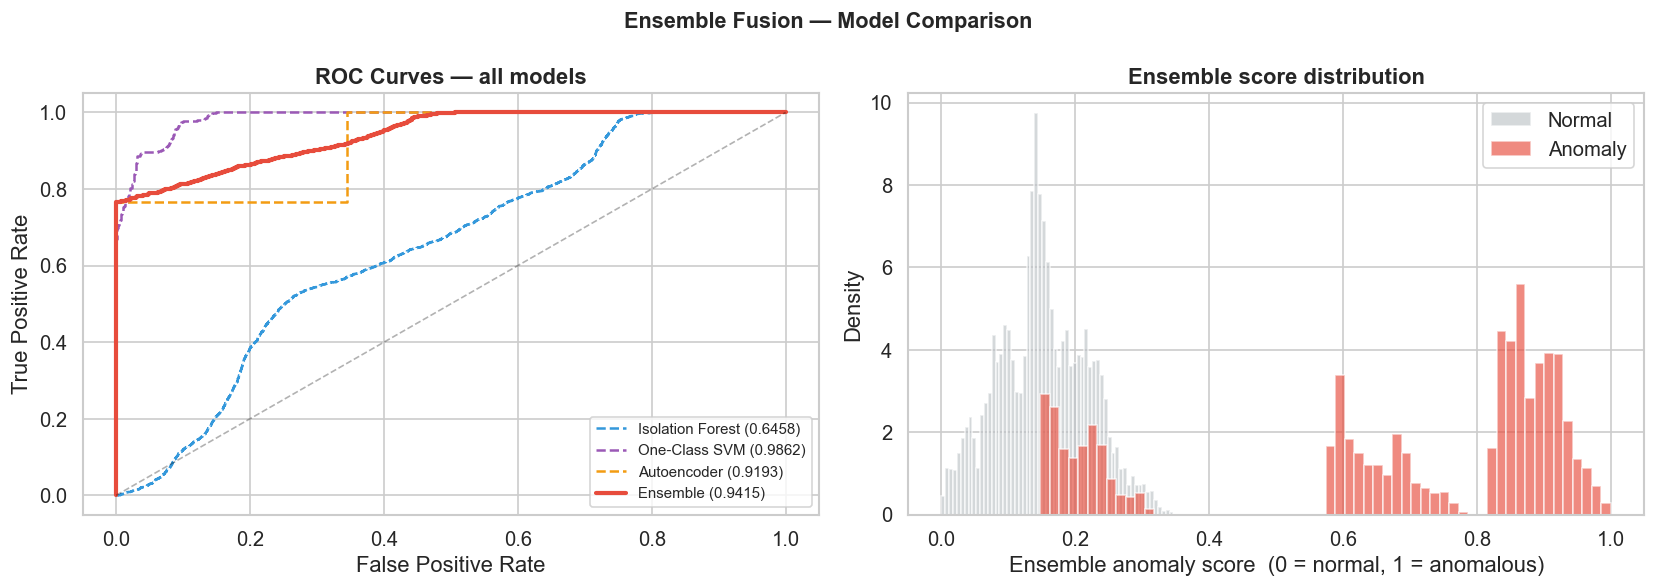

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves
ax = axes[0]
all_scores_plot = SCORES_TR + [ens_tr]
all_names_plot  = MODEL_NAMES + ['Ensemble']
all_cols_plot   = MODEL_COLORS + ['#e74c3c']

for sc, nm, col in zip(all_scores_plot, all_names_plot, all_cols_plot):
    fpr, tpr, _ = roc_curve(y_clean, sc)
    auc = roc_auc_score(y_clean, sc)
    ax.plot(fpr, tpr, lw=2.5 if nm=='Ensemble' else 1.5,
            ls='-' if nm=='Ensemble' else '--',
            color=col, label=f'{nm} ({auc:.4f})')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.3)
ax.set_title('ROC Curves — all models', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=9, loc='lower right')

# Ensemble score distribution
ax = axes[1]
for lab, col, nm in [(0,'#bdc3c7','Normal'),(1,'#e74c3c','Anomaly')]:
    ax.hist(ens_tr[y_clean==lab], bins=60, alpha=0.65,
            color=col, label=nm, edgecolor='white', density=True)
ax.set_title('Ensemble score distribution', fontweight='bold')
ax.set_xlabel('Ensemble anomaly score  (0 = normal, 1 = anomalous)')
ax.set_ylabel('Density')
ax.legend()

plt.suptitle('Ensemble Fusion — Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<a id='9'></a>
---
## 9. Evaluation & Calibration

We assess three dimensions:  
**Discrimination** (AUC-ROC, Avg Precision) · **Calibration** (reliability diagram) · **Threshold selection** (F1/Precision/Recall curve).

All metrics use **clean domain labels** as ground truth.

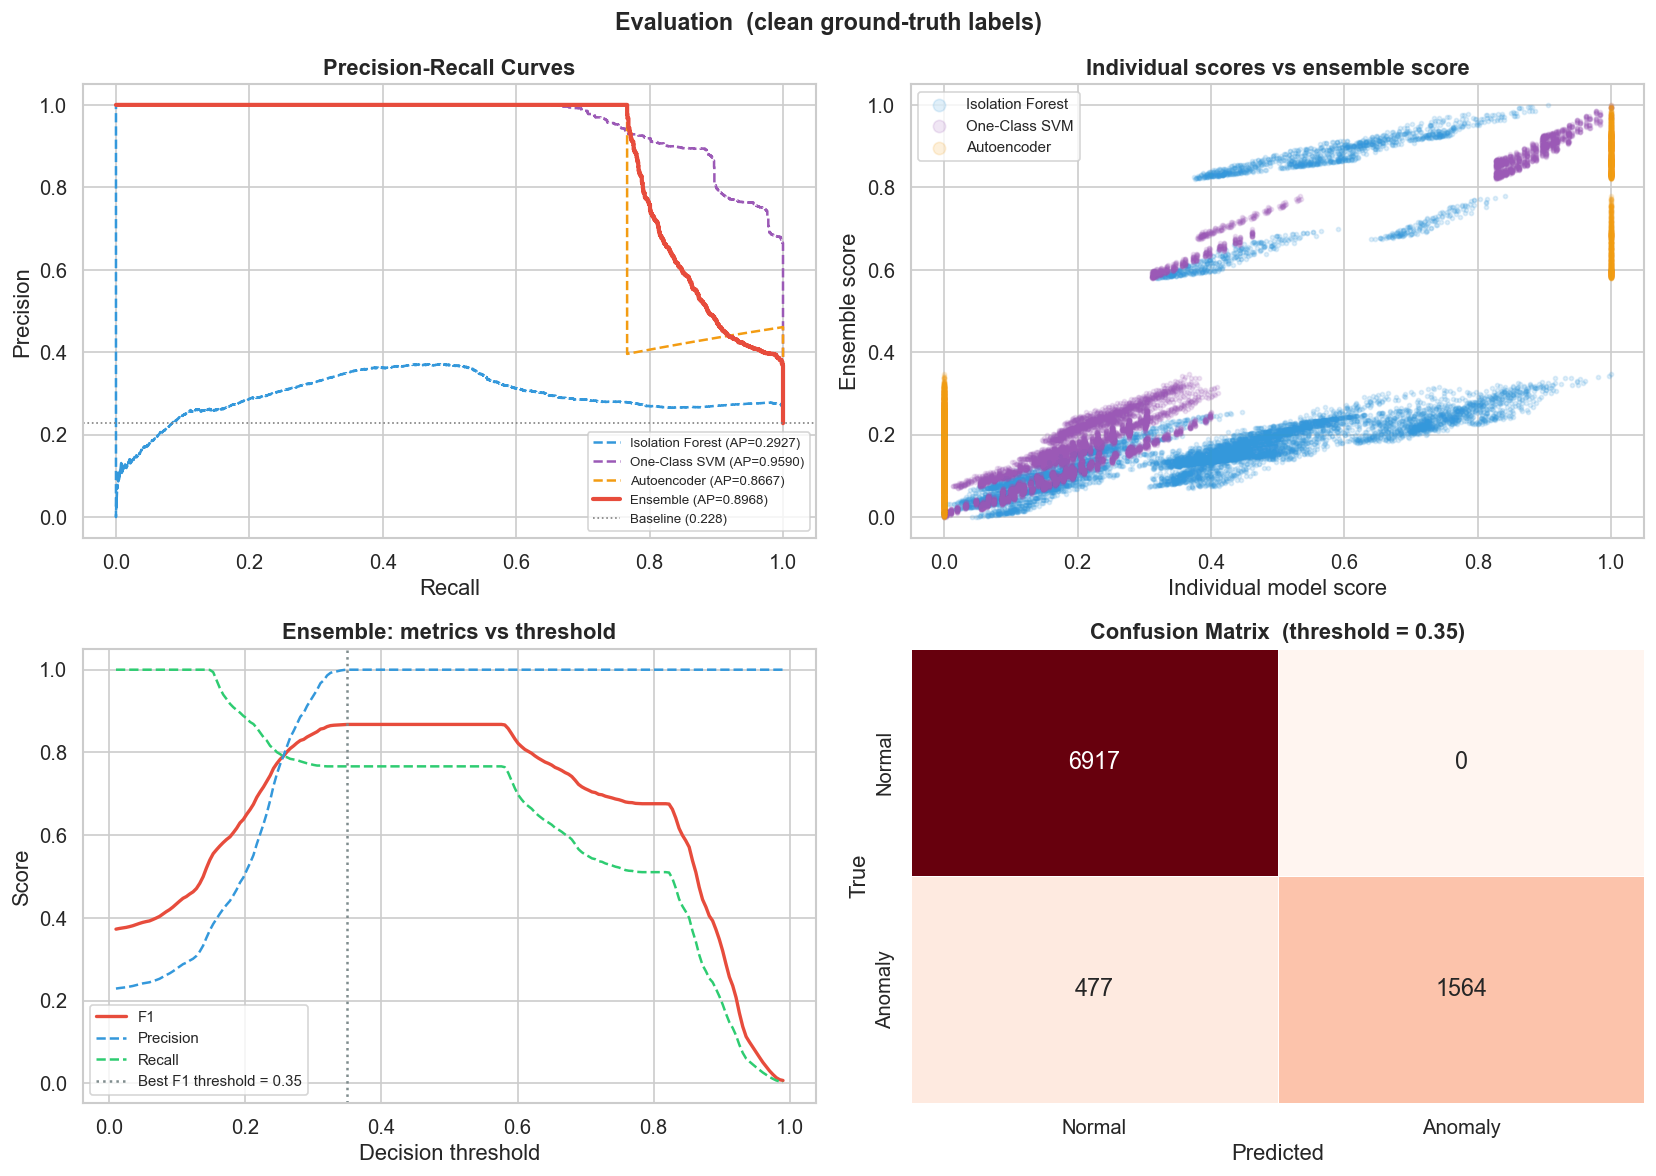

Optimal threshold : 0.350
F1 at threshold   : 0.8677

              precision    recall  f1-score   support

      Normal       0.94      1.00      0.97      6917
     Anomaly       1.00      0.77      0.87      2041

    accuracy                           0.95      8958
   macro avg       0.97      0.88      0.92      8958
weighted avg       0.95      0.95      0.94      8958



In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── 10.1 Precision-Recall curves ─────────────────────────────────────────────
ax = axes[0, 0]
for sc, nm, col in zip(all_scores_plot, all_names_plot, all_cols_plot):
    prec, rec, _ = precision_recall_curve(y_clean, sc)
    ap = average_precision_score(y_clean, sc)
    ax.plot(rec, prec, lw=2.5 if nm=='Ensemble' else 1.5,
            ls='-' if nm=='Ensemble' else '--',
            color=col, label=f'{nm} (AP={ap:.4f})')
ax.axhline(y_clean.mean(), color='gray', lw=1, ls=':',
           label=f'Baseline ({y_clean.mean():.3f})')
ax.set_title('Precision-Recall Curves', fontweight='bold')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(fontsize=8)

# ── 10.2 Score correlation between models ───────────────────────────────────
ax = axes[0, 1]
sc_df = pd.DataFrame({'Isolation Forest': sIF_tr, 'One-Class SVM': sOC_tr, 'Autoencoder': sAE_tr})
for col, color in zip(sc_df.columns, MODEL_COLORS):
    ax.scatter(sc_df[col], ens_tr, alpha=0.15, s=6, color=color, label=col)
ax.set_title('Individual scores vs ensemble score', fontweight='bold')
ax.set_xlabel('Individual model score')
ax.set_ylabel('Ensemble score')
ax.legend(fontsize=9, markerscale=3)

# ── 10.3 F1 / Precision / Recall vs threshold (ensemble) ─────────────────────
ax = axes[1, 0]
thresholds = np.linspace(0.01, 0.99, 200)

f1_th   = [f1_score(y_clean, (ens_tr>=t).astype(int), zero_division=0) for t in thresholds]
prec_th = [(y_clean[ens_tr>=t].mean() if (ens_tr>=t).sum()>0 else 0) for t in thresholds]
rec_th  = [(ens_tr[y_clean==1]>=t).mean() for t in thresholds]

best_idx  = int(np.argmax(f1_th))
BEST_THRESH = float(thresholds[best_idx])

ax.plot(thresholds, f1_th,   color='#e74c3c', lw=2,   label='F1')
ax.plot(thresholds, prec_th, color='#3498db', lw=1.5, ls='--', label='Precision')
ax.plot(thresholds, rec_th,  color='#2ecc71', lw=1.5, ls='--', label='Recall')
ax.axvline(BEST_THRESH, color='#7f8c8d', lw=1.5, ls=':',
           label=f'Best F1 threshold = {BEST_THRESH:.2f}')
ax.set_title('Ensemble: metrics vs threshold', fontweight='bold')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.legend(fontsize=9)

# ── 10.4 Confusion matrix ─────────────────────────────────────────────────────
ax = axes[1, 1]
y_pred = (ens_tr >= BEST_THRESH).astype(int)
cm = confusion_matrix(y_clean, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax,
            xticklabels=['Normal','Anomaly'],
            yticklabels=['Normal','Anomaly'],
            linewidths=0.5, cbar=False, annot_kws={'size': 14})
ax.set_title(f'Confusion Matrix  (threshold = {BEST_THRESH:.2f})', fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.suptitle('Evaluation  (clean ground-truth labels)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Optimal threshold : {BEST_THRESH:.3f}')
print(f'F1 at threshold   : {f1_th[best_idx]:.4f}')
print()
print(classification_report(y_clean, y_pred, target_names=['Normal','Anomaly']))

<a id='10'></a>
---
## 10. Risk Tiers & Final Output

| Tier | Score range | Operational action |
|---|---|---|
| 🟢 **Low**    | < 0.35 | Normal — no action required |
| 🟡 **Medium** | 0.35 – 0.65 | Monitor — flag for SLA review |
| 🔴 **High**   | > 0.65 | Alert — reroute to correct slice immediately |

In [16]:
LOW_T  = 0.35
HIGH_T = 0.65


def risk_tier(scores: np.ndarray) -> np.ndarray:
    return np.where(scores < LOW_T, 'Low',
           np.where(scores < HIGH_T, 'Medium', 'High'))


train['anomaly_score']     = ens_tr
train['risk_tier']         = risk_tier(ens_tr)
train['predicted_anomaly'] = (ens_tr >= BEST_THRESH).astype(int)

test['anomaly_score']      = ens_te
test['risk_tier']          = risk_tier(ens_te)
test['predicted_anomaly']  = (ens_te >= BEST_THRESH).astype(int)

print('Risk tier distribution — TRAIN (precision check against clean labels):')
for tier in ['High', 'Medium', 'Low']:
    n    = (train['risk_tier']==tier).sum()
    pct  = n / len(train) * 100
    prec = train.loc[train['risk_tier']==tier, 'is_anomaly'].mean() * 100
    print(f'  {tier:<8}: {n:5,} ({pct:5.1f}%)  — true anomaly rate in tier: {prec:.1f}%')

print()
print('Risk tier distribution — TEST:')
for tier in ['High', 'Medium', 'Low']:
    n   = (test['risk_tier']==tier).sum()
    pct = n / len(test) * 100
    print(f'  {tier:<8}: {n:5,} ({pct:5.1f}%)')

Risk tier distribution — TRAIN (precision check against clean labels):
  High    : 1,277 ( 14.3%)  — true anomaly rate in tier: 100.0%
  Medium  :   287 (  3.2%)  — true anomaly rate in tier: 100.0%
  Low     : 7,394 ( 82.5%)  — true anomaly rate in tier: 6.5%

Risk tier distribution — TEST:
  High    : 1,285 ( 14.3%)
  Medium  :   290 (  3.2%)
  Low     : 7,385 ( 82.4%)


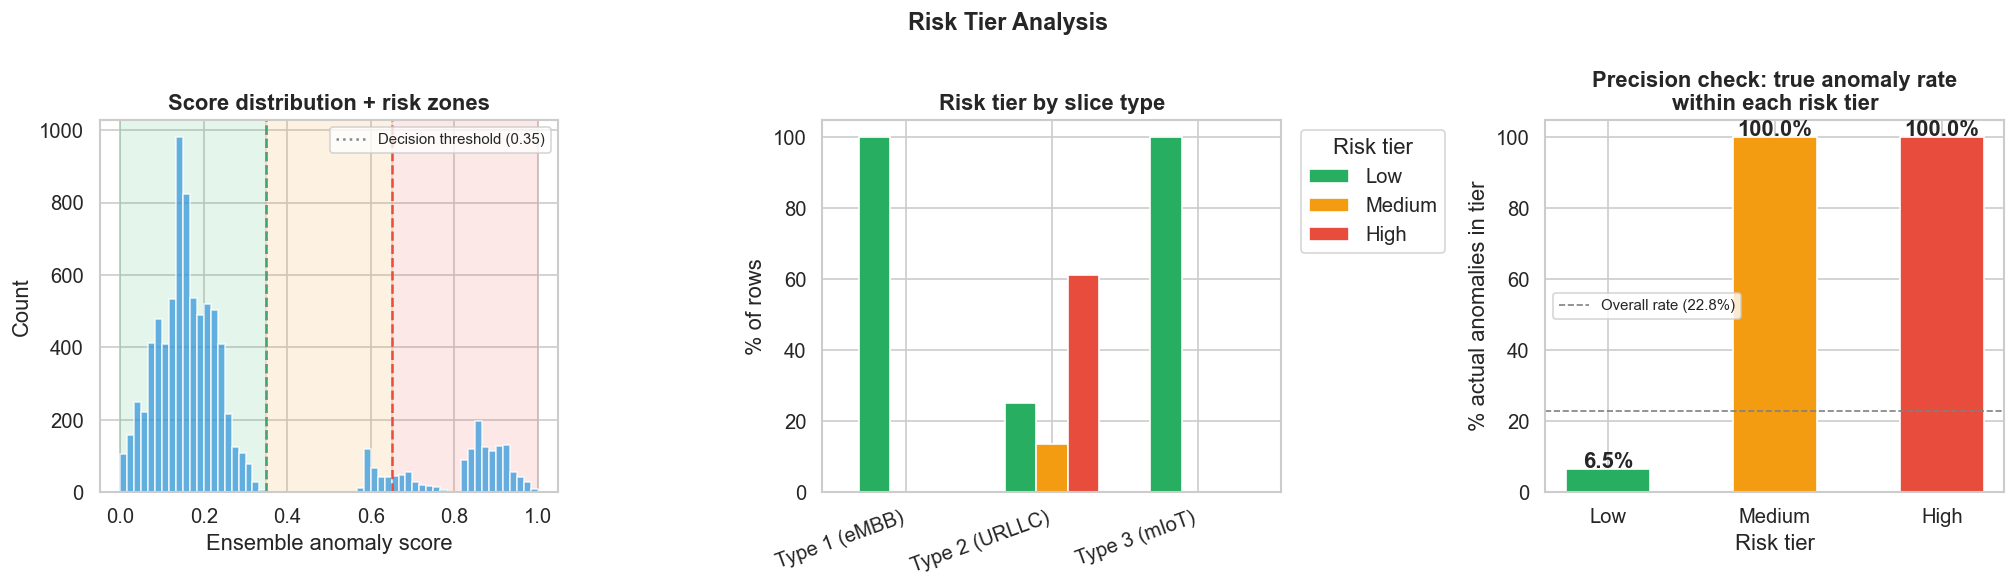

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── 12.1 Score distribution with tier zones ──────────────────────────────────
ax = axes[0]
ax.hist(ens_tr, bins=60, color='#3498db', alpha=0.75, edgecolor='white', zorder=2)
ax.axvspan(0,    LOW_T,  alpha=0.12, color='#27ae60')
ax.axvspan(LOW_T, HIGH_T, alpha=0.12, color='#f39c12')
ax.axvspan(HIGH_T, 1,     alpha=0.12, color='#e74c3c')
ax.axvline(LOW_T,     color='#27ae60', lw=1.5, ls='--')
ax.axvline(HIGH_T,    color='#e74c3c', lw=1.5, ls='--')
ax.axvline(BEST_THRESH, color='#7f8c8d', lw=1.5, ls=':',
           label=f'Decision threshold ({BEST_THRESH:.2f})')
ax.set_title('Score distribution + risk zones', fontweight='bold')
ax.set_xlabel('Ensemble anomaly score')
ax.set_ylabel('Count')
ax.legend(fontsize=9)

# ── 12.2 Risk tier by slice type ─────────────────────────────────────────────
ax = axes[1]
ct = pd.crosstab(train['slice Type'], train['risk_tier'],
                 normalize='index')[['Low','Medium','High']] * 100
ct.index = [SLICE_LABELS[i] for i in ct.index]
ct.plot(kind='bar', ax=ax, color=[TIER_PAL[t] for t in ct.columns],
        edgecolor='white', width=0.65)
ax.set_title('Risk tier by slice type', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('% of rows')
ax.set_xticklabels(ct.index, rotation=20, ha='right')
ax.legend(title='Risk tier', bbox_to_anchor=(1.02, 1.0))

# ── 12.3 True anomaly rate within each tier ───────────────────────────────────
ax = axes[2]
tier_prec = (train.groupby('risk_tier')['is_anomaly']
             .mean().reindex(['Low','Medium','High']) * 100)
bars = ax.bar(tier_prec.index, tier_prec.values,
              color=[TIER_PAL[t] for t in tier_prec.index],
              edgecolor='white', width=0.5)
for bar, val in zip(bars, tier_prec.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}%', ha='center', fontweight='bold')
ax.axhline(y_clean.mean()*100, color='gray', ls='--', lw=1,
           label=f'Overall rate ({y_clean.mean()*100:.1f}%)')
ax.set_title('Precision check: true anomaly rate\nwithin each risk tier', fontweight='bold')
ax.set_xlabel('Risk tier'); ax.set_ylabel('% actual anomalies in tier')
ax.legend(fontsize=9)

plt.suptitle('Risk Tier Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# Final output files
train[['anomaly_score','risk_tier','predicted_anomaly','is_anomaly']].to_csv(
    'train_anomaly_output.csv', index=False)
test[['anomaly_score','risk_tier','predicted_anomaly']].to_csv(
    'test_anomaly_output.csv', index=False)

print('Output files saved ✔')
print()
print('test_anomaly_output.csv summary:')
print(f'  Total test rows     : {len(test):,}')
print(f'  Predicted anomalies : {test["predicted_anomaly"].sum():,} '
      f'({test["predicted_anomaly"].mean()*100:.1f}%)')
for tier in ['High','Medium','Low']:
    n = (test['risk_tier']==tier).sum()
    print(f'  {tier} risk           : {n:,} ({n/len(test)*100:.1f}%)')
print()
test[['anomaly_score','risk_tier','predicted_anomaly']].head(10)

Output files saved ✔

test_anomaly_output.csv summary:
  Total test rows     : 8,960
  Predicted anomalies : 1,575 (17.6%)
  High risk           : 1,285 (14.3%)
  Medium risk           : 290 (3.2%)
  Low risk           : 7,385 (82.4%)



,anomaly_score,risk_tier,predicted_anomaly
0,0.151029,Low,0
1,0.206916,Low,0
2,0.150999,Low,0
3,0.212062,Low,0
4,0.148317,Low,0
5,0.136250,Low,0
6,0.137781,Low,0
7,0.840046,High,1
8,0.318483,Low,0
9,0.030453,Low,0


<a id='11'></a>
---
## 11. Summary

### Pipeline recap

```
Raw data (8 958 deduplicated rows)
   │
   ├─ Feature engineering (drop redundant, cyclic time, log-QoS, strictness, interactions)
   │
   ├─ Domain-rule labels (3 rules: GBR+PLR, GBR+delay, Slice2+NonGBR) → evaluation only
   │
   ├─ [1] Isolation Forest     (fits full dataset,    unsupervised)
   ├─ [2] One-Class SVM        (fits normal subset,   semi-supervised)
   └─ [3] Reconstruction AE    (fits normal subset,   semi-supervised)
               │
               └─ AUC²-weighted ensemble  →  anomaly_score ∈ [0,1]  →  risk_tier
```

### Design principles

- **Purely unsupervised detection:** No labels enter the models themselves — the 3 detectors find anomalies from the data geometry alone.
- **Domain-rule labels for evaluation only:** Ground truth is used to tune hyperparameters (contamination, nu, AE components) and measure AUC — not to train the detectors.
- **Normal-only OC-SVM and AE:** Tighter anomaly boundary than full-dataset training; the models learn what *normal* looks like and flag deviations.
- **AUC²-weighted fusion:** Rewards discriminative models without discarding weaker ones entirely.

### Strongest anomaly signals (from AE reconstruction error)
1. `gbr_x_strict` — premium traffic under strict QoS requirements
2. `log_plr` / `log_delay` — raw QoS parameter values  
3. `qos_strictness` — composite SLA sensitivity
4. `GBR` — premium traffic flag
5. `oc_score` / `ae_score` — distance from normal cluster

### Output columns
| Column | Description |
|---|---|
| `anomaly_score` | Continuous risk ∈ [0, 1]; higher = more anomalous |
| `risk_tier` | `Low` / `Medium` / `High` |
| `predicted_anomaly` | Binary at optimal F1 threshold |
| `is_anomaly` | Ground-truth label (train only) |
